# Hypergrid Environment Difficulty Comparison

This notebook compares **all 7 reward functions** available for the HyperGrid environment by training identical VarGrad (Log Partition Variance) GFlowNet models on each and measuring:

1. **Mode discovery** — what % of the true modes does the model find over training?
2. **Terminal state density** — where in state space does the trained model sample?

All experiments use the same architecture, optimizer, and training budget so that differences reflect the intrinsic difficulty of each reward landscape.

**Setup**: D=4 dimensions, H=16 height, 100K training trajectories.

In [6]:
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from gfn.estimators import DiscretePolicyEstimator
from gfn.gflownet import LogPartitionVarianceGFlowNet
from gfn.gym import HyperGrid
from gfn.gym.hypergrid import get_reward_presets
from gfn.preprocessors import KHotPreprocessor
from gfn.samplers import Sampler
from gfn.states import DiscreteStates
from gfn.utils.common import set_seed
from gfn.utils.modules import MLP, DiscreteUniform

# Force CPU — MPS causes device-mismatch overhead in reward functions.
device = torch.device("cpu")
print(f"Using device: {device}")

# Shared experiment parameters
D = 4        # dimensions
H = 32       # height (grid size per dimension)
N_TRAJECTORIES = 100_000
BATCH_SIZE = 256
HIDDEN_DIM = 256
N_HIDDEN = 2
LR = 1e-3
VALIDATION_INTERVAL = 20  # every 20 batches (~5K trajectories)
FINAL_SAMPLES = 10_000
SEED = 42

Using device: cpu


## The Reward Functions

| Reward | What it computes | What makes it hard |
|--------|------------------|--------------------|
| **Original** | Concentric rings (R1) + thin band (R2) on top of base R0. Modes at the Cartesian product of band indices across dims. | Modes are narrow and far from origin; model must traverse empty base-reward space to reach corners. |
| **Sparse** | Binary: reward ≈ 1 only at a small set of target states (permutations of {0, 1, H−2}); ≈ ε elsewhere. | Needle-in-haystack — almost no reward signal until a target is hit. Extremely sparse gradient. |
| **Deceptive** | Like Original, but the center region gets +R1 while the outer ring *loses* R1. Modes are still in the thin band. | Center acts as a strong attractor (high reward), pulling the model away from the true mode band at the edges. |
| **BitwiseXOR** | Tiered GF(2) parity constraints on bit-planes across dimensions. Higher tiers constrain more bits. | Compositional/fractal structure; satisfying all tiers requires coordinating bit-level patterns across dims. |
| **MultiplicativeCoprime** | Tiered prime-factorization constraints with exponent caps and optional coprimality/LCM targets. | Number-theoretic coupling between dimensions; model must implicitly learn prime structure of coordinate values. |
| **ConditionalMultiScale** | Base-B digit decomposition where each tier's constraint depends on finer-scale digits (conditional hierarchy). | Hierarchical — learning tier t requires first learning tiers 1..t−1. Cross-scale dependency is the key challenge. |

> **Note:** Cosine reward is excluded — its oscillatory structure requires H≥32 to produce any modes.

## Environment Configuration & Mode Tuning

We start from the "medium" preset for each reward function, with several adjustments for D=4, H=16:

- **Compositional rewards** (bitwise_xor, multiplicative_coprime, conditional_multiscale) default to `R0=0.0`, meaning most states get zero reward. Since VarGrad requires `log R(x)`, this produces `-inf` and NaN gradients. We set `R0=0.1` for all environments (matching the original reward).

- **conditional_multiscale** requires H to be a power of its base. Since H=16 is not a power of 4, we use `base=2` (16 = 2⁴).

- **bitwise_xor** medium preset requests bits 0–7, but H=16 values only have 4 bits (0–3). Bits 4–7 are always zero, so the default single parity check is trivially satisfied, yielding 4096 modes (6.25% of the state space). We replace this with a custom config: 2 parity checks on 1 tier across all 4 bit-planes, which tightens the constraint to 256 modes (0.39%).

- **cosine** is excluded — its oscillatory reward structure requires H≥32 to resolve any modes.

- **sparse** has no tunable reward kwargs — its mode count is determined by D and H.

In [7]:
# Assign a color to each environment using a qualitative palette.
# Note: cosine is excluded — its oscillatory reward requires H>=32 to resolve modes.
COLORS = {
    "original": "#1f77b4",
    "sparse": "#2ca02c",
    "deceptive": "#d62728",
    "bitwise_xor": "#9467bd",
    "multiplicative_coprime": "#8c564b",
    "conditional_multiscale": "#e377c2",
}

# Start from "medium" presets and inspect mode counts.
env_configs = {}
for name in COLORS:
    preset = get_reward_presets(name, D, H)["medium"]
    # conditional_multiscale needs base=2 for H that isn't a power of 4.
    if name == "conditional_multiscale":
        preset["base"] = 2
        preset["filter_width"] = 1  # base // 2
    # bitwise_xor medium preset requests bits 0-7 but H=16 only has 4 bits,
    # making the default single parity check trivially weak (4096 modes / 6.25%).
    # Use 2 parity checks on 1 tier across all 4 bit-planes → 256 modes (0.39%).
    if name == "bitwise_xor":
        preset = dict(
            R0=0.1,
            tier_weights=[10.0],
            dims_constrained=[0, 1, 2, 3],
            bits_per_tier=[(0, 3)],
            parity_checks=[
                {"A": torch.tensor([[1,1,0,0],[0,0,1,1]]), "c": torch.tensor([0,0])},
            ],
        )
    # Compositional rewards default to R0=0.0, which causes log(0)=-inf in VarGrad.
    # Use R0=0.1 (same as original) so all environments have a finite base reward.
    if preset.get("R0", None) == 0.0:
        preset["R0"] = 0.1
    env_configs[name] = preset

# Compute mode counts directly (no store_all_states to avoid multiprocessing crashes in Jupyter).
all_states = torch.cartesian_prod(*[torch.arange(H, dtype=torch.long) for _ in range(D)])
print(f"State space: {H}^{D} = {len(all_states):,} states\n")
print(f"{'Environment':<30s} {'Modes':>10s} {'% of state space':>18s}")
print("-" * 62)

env_mode_counts = {}
for name, kwargs in env_configs.items():
    env = HyperGrid(
        ndim=D, height=H,
        reward_fn_str=name,
        reward_fn_kwargs=kwargs,
        device="cpu",
        validate_modes=False,
    )
    rewards = env.reward_fn(all_states)
    threshold = env._mode_reward_threshold()
    n_modes = int((rewards >= threshold).sum().item())
    env_mode_counts[name] = n_modes
    pct = 100 * n_modes / len(all_states)
    print(f"{name:<30s} {n_modes:>10} {pct:>17.4f}%")

State space: 32^4 = 1,048,576 states

Environment                         Modes   % of state space
--------------------------------------------------------------
original                             1296            0.1236%
sparse                                 15            0.0014%
deceptive                            1296            0.1236%
bitwise_xor                          4096            0.3906%


/Users/jdv/code/torchgfn/src/gfn/env.py:572: UserWarning: You're using advanced parameters: (sf). These are only needed for custom action handling. For basic environments, you can omit these.
  warnings.warn(


multiplicative_coprime              12708            1.2119%
conditional_multiscale              65536            6.2500%


## Training Function

We train a VarGrad (Log Partition Variance) GFlowNet with:
- Forward policy: 2-layer MLP (256 hidden units)
- Backward policy: uniform
- Optimizer: Adam, lr=1e-3
- Gradient clipping: max norm 1.0

Mode discovery is tracked cumulatively: we record the set of unique mode states visited across all training trajectories.

In [8]:
import time

def train_one_env(
    name: str,
    reward_fn_str: str,
    reward_fn_kwargs: dict,
    color: str,
    n_trajectories: int = N_TRAJECTORIES,
    batch_size: int = BATCH_SIZE,
    hidden_dim: int = HIDDEN_DIM,
    n_hidden: int = N_HIDDEN,
    lr: float = LR,
    validation_interval: int = VALIDATION_INTERVAL,
    seed: int = SEED,
    epsilon: float = 0.1,
) -> dict:
    """Train a VarGrad GFlowNet on a single HyperGrid environment.

    Returns a dict with training curves and final samples for plotting.
    """
    set_seed(seed)

    # --- Environment ---
    env = HyperGrid(
        ndim=D, height=H,
        reward_fn_str=reward_fn_str,
        reward_fn_kwargs=reward_fn_kwargs,
        device=device,
        validate_modes=False,
    )
    mode_threshold = env._mode_reward_threshold()

    # --- Model ---
    preprocessor = KHotPreprocessor(height=H, ndim=D)
    module_PF = MLP(
        input_dim=preprocessor.output_dim,
        output_dim=env.n_actions,
        hidden_dim=hidden_dim,
        n_hidden_layers=n_hidden,
    )
    module_PB = DiscreteUniform(output_dim=env.n_actions - 1)

    pf_estimator = DiscretePolicyEstimator(
        module_PF, env.n_actions, preprocessor=preprocessor, is_backward=False,
    )
    pb_estimator = DiscretePolicyEstimator(
        module_PB, env.n_actions, preprocessor=preprocessor, is_backward=True,
    )
    gflownet = LogPartitionVarianceGFlowNet(
        pf=pf_estimator, pb=pb_estimator,
    ).to(device)

    optimizer = torch.optim.Adam(gflownet.pf_pb_parameters(), lr=lr)
    sampler = Sampler(estimator=pf_estimator)

    # --- Training loop ---
    n_iterations = n_trajectories // batch_size
    discovered_modes: set[tuple] = set()
    n_total = env_mode_counts[name]

    mode_pct_history = []
    loss_history = []
    traj_axis = []
    new_terminating_states: list[torch.Tensor] = []

    for it in tqdm(range(n_iterations), desc=name, leave=False):
        t0 = time.perf_counter()

        t_sample_start = time.perf_counter()
        # save_logprobs=False for off-policy exploration (epsilon tempering).
        trajectories = sampler.sample_trajectories(
            env, n=batch_size, save_logprobs=False, save_estimator_outputs=False,
            epsilon=epsilon,
        )
        t_sample = time.perf_counter() - t_sample_start

        new_terminating_states.append(trajectories.terminating_states.tensor)

        t_loss_start = time.perf_counter()
        optimizer.zero_grad()
        loss = gflownet.loss_from_trajectories(env, trajectories)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gflownet.parameters(), 1.0)
        optimizer.step()
        t_loss = time.perf_counter() - t_loss_start

        t_mode = 0.0
        if (it + 1) % validation_interval == 0:
            t_mode_start = time.perf_counter()
            batch = torch.cat(new_terminating_states, dim=0)
            rewards = env.reward_fn(batch)
            mask = rewards >= mode_threshold
            if mask.any():
                for s in batch[mask]:
                    discovered_modes.add(tuple(s.tolist()))
            new_terminating_states.clear()
            t_mode = time.perf_counter() - t_mode_start

            pct = 100 * len(discovered_modes) / n_total if n_total else 0.0
            mode_pct_history.append(pct)
            loss_history.append(loss.item())
            traj_axis.append((it + 1) * batch_size)

        t_total = time.perf_counter() - t0
        if it < 3:
            avg_len = trajectories.terminating_idx.float().mean().item()
            print(f"  [{name}] batch {it}: total={t_total:.3f}s  "
                  f"sample={t_sample:.3f}s  loss+step={t_loss:.3f}s  "
                  f"modes={t_mode:.3f}s  avg_traj_len={avg_len:.1f}")

    # --- Final sampling (on-policy, no exploration) ---
    with torch.no_grad():
        final_trajs = sampler.sample_trajectories(
            env, n=FINAL_SAMPLES, save_logprobs=False, save_estimator_outputs=False,
        )
    final_states = final_trajs.terminating_states.tensor.numpy()

    return {
        "name": name,
        "color": color,
        "mode_pct_history": mode_pct_history,
        "loss_history": loss_history,
        "traj_axis": traj_axis,
        "n_modes_total": n_total,
        "final_states": final_states,
    }

## Train All Environments

This trains 7 independent GFlowNets sequentially (one per reward function). Each run takes 100K / 256 ≈ 390 gradient steps.

In [9]:
results = []
for name, kwargs in tqdm(env_configs.items(), desc="Environments", total=len(env_configs)):
    result = train_one_env(
        name=name,
        reward_fn_str=name,
        reward_fn_kwargs=kwargs,
        color=COLORS[name],
    )
    print(f"  {name}: final mode discovery = {result['mode_pct_history'][-1]:.1f}% "
          f"({result['n_modes_total']} total modes)")
    results.append(result)

Environments:   0%|          | 0/6 [00:00<?, ?it/s]

  [original] batch 0: total=0.034s  sample=0.028s  loss+step=0.005s  modes=0.000s  avg_traj_len=4.7
  [original] batch 1: total=0.031s  sample=0.026s  loss+step=0.004s  modes=0.000s  avg_traj_len=5.7
  [original] batch 2: total=0.027s  sample=0.021s  loss+step=0.006s  modes=0.000s  avg_traj_len=6.1


Environments:  17%|█▋        | 1/6 [00:35<02:57, 35.48s/it]

  original: final mode discovery = 7.6% (1296 total modes)


  [sparse] batch 0: total=0.024s  sample=0.019s  loss+step=0.004s  modes=0.000s  avg_traj_len=4.7
  [sparse] batch 1: total=0.029s  sample=0.024s  loss+step=0.005s  modes=0.000s  avg_traj_len=5.7
  [sparse] batch 2: total=0.027s  sample=0.022s  loss+step=0.006s  modes=0.000s  avg_traj_len=6.1


...

Environments:  83%|████████▎ | 5/6 [03:05<00:36, 36.82s/it]

  multiplicative_coprime: final mode discovery = 26.2% (12708 total modes)


  [conditional_multiscale] batch 0: total=0.038s  sample=0.019s  loss+step=0.019s  modes=0.000s  avg_traj_len=4.7
  [conditional_multiscale] batch 1: total=0.038s  sample=0.032s  loss+step=0.006s  modes=0.000s  avg_traj_len=5.5
  [conditional_multiscale] batch 2: total=0.026s  sample=0.021s  loss+step=0.005s  modes=0.000s  avg_traj_len=5.9


Environments: 100%|██████████| 6/6 [03:40<00:00, 36.70s/it]

  conditional_multiscale: final mode discovery = 11.8% (65536 total modes)


## Results

**Top**: Mode discovery curves — % of total modes found as a function of training trajectories.

**Bottom**: 2D marginal density heatmaps (dims 0 vs 1) of 10K terminal states sampled from each trained model.

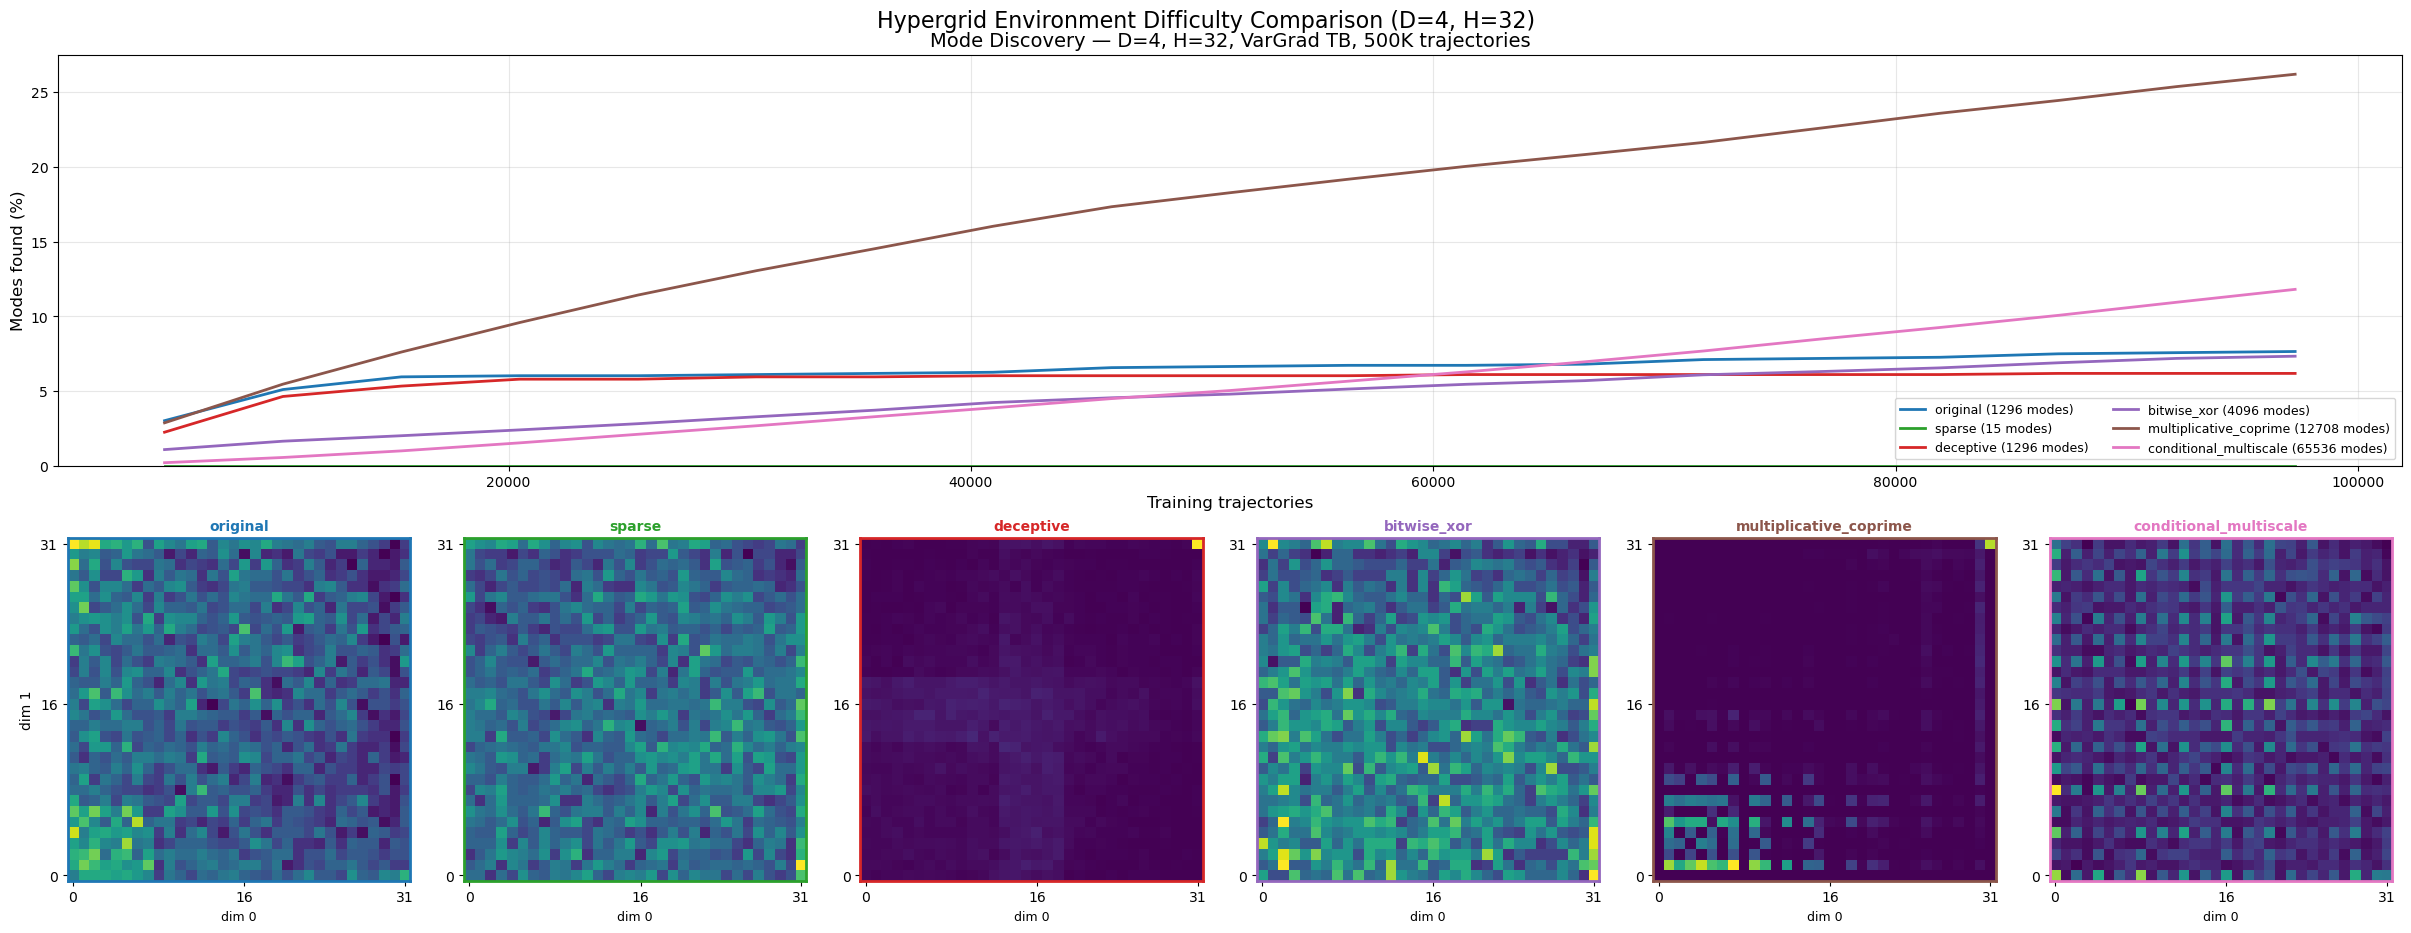

In [ ]:
n_envs = len(results)

fig = plt.figure(figsize=(4 * n_envs, 9), constrained_layout=True)
gs = fig.add_gridspec(2, n_envs, height_ratios=[1.2, 1])

# --- Top row: mode discovery curves (single axes spanning all columns) ---
ax_top = fig.add_subplot(gs[0, :])
for r in results:
    label = f"{r['name']} ({r['n_modes_total']} modes)"
    ax_top.plot(r["traj_axis"], r["mode_pct_history"], color=r["color"], label=label, linewidth=2)
ax_top.set_xlabel("Training trajectories", fontsize=12)
ax_top.set_ylabel("Modes found (%)", fontsize=12)
ax_top.set_title(f"Mode Discovery — D={D}, H={H}, VarGrad TB, 500K trajectories", fontsize=14)
ax_top.legend(fontsize=9, loc="lower right", ncol=2)
ax_top.set_ylim(bottom=0)
ax_top.grid(True, alpha=0.3)

# --- Bottom row: 2D marginal heatmaps (one per environment) ---
for i, r in enumerate(results):
    ax = fig.add_subplot(gs[1, i])
    states = r["final_states"]  # (N, D) array of ints
    # 2D histogram of dims 0 and 1
    hist, xedges, yedges = np.histogram2d(
        states[:, 0], states[:, 1],
        bins=np.arange(H + 1) - 0.5,
        density=True,
    )
    im = ax.imshow(
        hist.T, origin="lower", aspect="equal",
        extent=[-0.5, H - 0.5, -0.5, H - 0.5],
        cmap="viridis", interpolation="nearest",
    )
    ax.set_title(r["name"], fontsize=10, color=r["color"], fontweight="bold")
    ax.set_xticks([0, H // 2, H - 1])
    ax.set_yticks([0, H // 2, H - 1])
    if i == 0:
        ax.set_ylabel("dim 1", fontsize=10)
    ax.set_xlabel("dim 0", fontsize=9)
    # Colored border
    for spine in ax.spines.values():
        spine.set_edgecolor(r["color"])
        spine.set_linewidth(2)

fig.suptitle(
    f"Hypergrid Environment Difficulty Comparison (D={D}, H={H})",
    fontsize=16, y=1.02,
)
plt.show()